In [1]:
# Setup for Google Colab (optional)
import sys
if 'google.colab' in sys.modules:
    print("Running in Google Colab")
    # Install required packages
    !pip install -q py4DSTEM hyperspy scikit-image matplotlib numpy scipy
    
    # Clone the repository to access data
    !git clone -q https://github.com/NU-MSE-LECTURES/465-WINTER2026.git
    import os
    os.chdir('/content/465-WINTER2026')
    
    # Set up file handling
    from google.colab import files
    print("Colab setup complete!")
else:
    print("Running in local environment")

Running in local environment


<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_02/assignments/assignment_02_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 02: 4D-STEM Foundations

Complete this assignment to demonstrate your understanding of 4D-STEM data analysis and calibration.


In [2]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing requirements...")
    !pip install hyperspy ase py4DSTEM
    !git clone https://github.com/NU-MSE-LECTURES/465_Computational_Microscopy_2026.git
    print("Setup complete.")
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab.")

Not running in Google Colab.


## Task 1: Distinguish Navigation vs. Signal Axes

In your notebook, define the "Navigation Axes" (where the measurement is made, e.g., x, y scan positions).

Define the "Signal Axes" (what is measured at each point, e.g., an EELS spectrum or a 2D diffraction pattern).

Use signal.axes manager to print and verify the dimensionality of a 4D-STEM dataset (expected: 2 Navigation, 2 Signal).

In [4]:
# Your code here
import hyperspy.api as hs

si_sige = hs.load('/Users/wkddk/matsci465/Si-SiGe.dm4')
s = si_sige.transpose(navigation_axes=[2,3],signal_axes=[0,1]) # the navigation and signal axes in this dataset need to be swapped

s.axes_manager.navigation_axes[0].name = 'Rx'
s.axes_manager.navigation_axes[1].name = 'Ry'

s.axes_manager.signal_axes[0].name = 'Qx'
s.axes_manager.signal_axes[1].name = 'Qy'

s.axes_manager

Navigation axis name,size,index,offset,scale,units
Rx,17,0,0.0,2.0,nm
Ry,77,0,0.0,2.0,nm
Signal axis name,size,,offset,scale,units
Qx,448,,0.0,0.06208537146449089,1/nm
Qy,480,,0.0,0.06208537146449089,1/nm


## Function for Virtual Detector Framework

In [153]:
# This function will generate a virtual image depending on user-specified imaging parameters

def create_virtual_image(datacube, shape, center, radius):
        if center >= (datacube.shape[2], datacube.shape[3]):
            print('The center position lies outside of the image.')
        elif not (np.min(radius) >= 0 and np.max(radius) >= 0 and center[0] - np.max(radius) >= 0 and center[1] - np.max(radius) >= 0 and center[0] + np.max(radius) <= datacube.shape[2] and center[1] + np.max(radius) <= datacube.shape[3]):
            print('The mask lies outside of the image.')
        else:
            real_pixel_size = datacube.calibration.get_R_pixel_size()
            rx = np.arange(datacube.shape[0]) * real_pixel_size
            ry = np.arange(datacube.shape[1]) * real_pixel_size
            
            datacube.get_dp_mean()
            datacube.position_detector(mode=shape, geometry=(center, radius))
            virtual_img = datacube.get_virtual_image(mode=shape, geometry=(center, radius))
    
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            
            im = ax.imshow(virtual_img.data, extent = [ry[0], ry[-1], rx[-1], rx[0]], cmap='magma', origin='upper')
            ax.set_xlabel('y (nm)', fontsize=12)
            ax.set_ylabel('x (nm)', fontsize=12)
            if shape == 'circle' and center == (datacube.shape[2]/2, datacube.shape[3]/2):
                ax.set_title('BF image', fontsize=12)
            elif shape == 'annular' and center == (datacube.shape[2]/2, datacube.shape[3]/2):
                ax.set_title('ADF image', fontsize=12)
            else:
                ax.set_title('Custom mask', fontsize=12)

            scale_len = 5
            scalebar = AnchoredSizeBar(
                transform=ax.transData,
                size=scale_len,
                label=f'{scale_len} nm',
                loc='lower right',
                pad=0.4,
                color='white',
                frameon=False,
                size_vertical=scale_len * 0.07
            )
            ax.add_artist(scalebar)
            plt.colorbar(im, ax=ax)
            plt.tight_layout()

            return fig, ax

## Task 2: Load and Calibrate 4D-STEM Data

Use py4DSTEM.io.read to load a 4D-STEM dataset (e.g., .dm4 or .h5).

**Note:** The dataset Si-SiGe.dm4 should be available in the raw_data folder.

Set the scan step size (real space calibration) using dataset.set_scan_step_size().

Perform Center of Mass (CoM) correction using dataset.get_diffraction_shifts() to center the unscattered beam.

In [73]:
# importing all necessary packages for the code

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import py4DSTEM as p4
from scipy.ndimage import center_of_mass, shift
from scipy.signal import find_peaks
print(f'py4DSTEM version: {p4.__version__}') # running on Python 3.11

py4DSTEM version: 0.14.0


In [74]:
sige_datacube = p4.io.import_file('C:/Users/wkddk/matsci465/Si-SiGe.dm4')
sige = sige_datacube.swap_RQ() # like before, the navigation and signal axes need to be swapped
sige.shape

(77, 17, 480, 448)

In [75]:
# these values were taken from the Hyperspy axis manager
sige.calibration.set_Q_pixel_size(0.06208537146449089*0.1)
sige.calibration.set_Q_pixel_units('A^-1')
sige.calibration.set_R_pixel_size(2.0)
sige.calibration.set_R_pixel_units('nm')
sige.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:    0.006208537146449089
             R_pixel_size:    2.0
             Q_pixel_units:   A^-1
             R_pixel_units:   nm
)

In [76]:
Rpix = sige.calibration.get_R_pixel_size()
Qpix = sige.calibration.get_Q_pixel_size()

sige.set_dim(0, [0, Rpix], units='nm', name="Rx")
sige.set_dim(1, [0, Rpix], units='nm', name="Ry")
sige.set_dim(2, (np.arange(480) - 240) * Qpix, units='A^-1', name="Qx")
sige.set_dim(3, (np.arange(448) - 224) * Qpix, units='A^-1', name="Qy")
sige

DataCube( A 4-dimensional array of shape (77, 17, 480, 448) called 'dm_dataset',
          with dimensions:

              Rx = [0.0,2.0,...] nm
              Ry = [0.0,2.0,...] nm
              Qx = [-1.4900489151477814,-1.4838403780013323,...] A^-1
              Qy = [-1.390712320804596,-1.3845037836581469,...] A^-1

## Saving calibration parameters

In [77]:
calib_params = {
    'R_pixel_size': Rpix,
    'R_pixel_units': 'nm',
    'Q_pixel_size': Qpix,
    'Q_pixel_units': 'A^-1'
}

## Function defitions for diffraction analysis routines

In [78]:
# Creates a circular mask to isolate the beam center in each DP
# This helps with CoM calculations down the line and helps center the DP more appropriately

def circular_mask(shape, center, radius):
    yy, xx = np.indices(shape)
    cx, cy = center
    r2 = (xx - cx)**2 + (yy - cy)**2
    return r2 <= radius**2


def beam_center_masked_com(dp, radius):
    h, w = dp.shape
    approx_center = (w/2, h/2)
    mask = circular_mask(dp.shape, approx_center, radius)
    dp_masked = dp * mask
    cy, cx = center_of_mass(dp_masked)
    return (cx, cy)

In [79]:
# Returns some CoM-based calibration parameters and the calibrated DPs themselves for a datacube

def com_calib(datacube):
    datacube_com = np.empty(shape = (datacube.data.shape[0], datacube.data.shape[1], 2))

    for i in range(datacube.data.shape[0]):
        for j in range(datacube.data.shape[1]):
            datacube_com[i,j,1], datacube_com[i,j,0] = beam_center_masked_com(datacube.data[i,j,:,:], 30)

    mean_DP = datacube.get_dp_mean()
    ref_com = center_of_mass(mean_DP.data)

    calib = np.empty(shape = (datacube.data.shape[0], datacube.data.shape[1], datacube.data.shape[2], datacube.data.shape[3]))
    shifts = np.empty(shape = (datacube.data.shape[0], datacube.data.shape[1], 2))

    for i in range(datacube.data.shape[0]):
        for j in range(datacube.data.shape[1]):
            x_shift, y_shift = ref_com[1] - datacube_com[i,j,1], ref_com[0] - datacube_com[i,j,0]
            shifts[i,j,:] = [y_shift, x_shift]
            calib[i,j,:,:] = shift(datacube.data[i,j,:,:], shift=(x_shift, y_shift), order=1, mode='nearest', prefilter=False)

    return datacube_com, ref_com, calib

In [154]:
# Finds the radial intensity profile based on a calibrated datacube

def find_radial_intensity_profile(calib_datacube, Q_pixel_size, Q_pixel_units, scale):
    dp = np.mean(calib_datacube, axis=(0,1)).astype(float)
    threshold = np.percentile(dp, 99.5)
    high_intensity_mask = dp > threshold
    if high_intensity_mask.any():
        origin_y, origin_x = center_of_mass(dp)
        print(f"Refined center from direct beam: ({origin_x:.2f}, {origin_y:.2f})")
    else:
        # Fallback to geometric center
        origin_x = dp.shape[1] / 2.0
        origin_y = dp.shape[0] / 2.0
        print(f"Using geometric center: ({origin_x:.2f}, {origin_y:.2f})")
    
    # Create coordinate grids
    y_coords, x_coords = np.ogrid[:dp.shape[0], :dp.shape[1]]
    r = np.sqrt((x_coords - origin_x)**2 + (y_coords - origin_y)**2)
    r_phys = r * Q_pixel_size

    H, W = dp.shape
    x0_pix = W / 2.0
    y0_pix = H / 2.0
    
    # physical half-widths
    half_x = (W * Q_pixel_size) / 2.0
    half_y = (H * Q_pixel_size) / 2.0
    
    extent_centered = [-half_x, half_x, -half_y, half_y]
    
    # Compute radial average
    r_int = r.astype(int)
    max_radius = int(np.sqrt(origin_x**2 + origin_y**2))
    max_radius_phys = max_radius * Q_pixel_size
    radial_profile = np.zeros(max_radius)
    radial_counts = np.zeros(max_radius)
    
    for radius in range(max_radius):
        mask = r_int == radius
        if mask.any():
            radial_profile[radius] = dp[mask].mean()
            radial_counts[radius] = mask.sum()
    
    # Use find_peaks with relaxed parameters to catch more reflections
    peaks_radii, peak_properties = find_peaks(radial_profile, 
                                              height=np.percentile(radial_profile[5:], 70),  # Skip center
                                              distance=3,
                                              prominence=0.01)
    
    # Filter out peaks too close to center (direct beam)
    peaks_radii = peaks_radii[peaks_radii > 3]
    peaks_radii_phys = peaks_radii * Q_pixel_size

    # Visualize the radial profile and detected peaks
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Diffraction pattern with radial rings at peak positions
    scalebar_length = scale # 1/nm or A^-1
    
    im = ax1.imshow(np.log1p(dp), cmap='gray', origin='upper', extent=extent_centered)
    ax1.set_xlabel(f'X ({Q_pixel_units})', fontsize=12)
    ax1.set_ylabel(f'Y ({Q_pixel_units})', fontsize=12)
    ax1.set_title('Average Diffraction Pattern with Bragg Rings', fontsize=13)
    
    scalebar = AnchoredSizeBar(
        transform=ax1.transData,
        size=scalebar_length,
        label=f"{scalebar_length} {Q_pixel_units}",
        loc="lower right",
        pad=0.4,
        color="white",
        frameon=False,
        size_vertical=scalebar_length * 0.07
    )
    ax1.add_artist(scalebar)
    
    # Draw circles at detected peak radii
    theta = np.linspace(0, 2*np.pi, 100)
    origin_x_phys = origin_x * Q_pixel_size
    origin_y_phys = origin_y * Q_pixel_size
    origin_x_nm = (origin_x - x0_pix) * Q_pixel_size
    origin_y_nm = (origin_y - y0_pix) * Q_pixel_size
    peaks_radii_nm = peaks_radii * Q_pixel_size  # if square pixels; see note below

    for i, r_peak_nm in enumerate(peaks_radii_nm):
        x_circle = origin_x_nm + r_peak_nm * np.cos(theta)
        y_circle = origin_y_nm + r_peak_nm * np.sin(theta)
        ax1.plot(x_circle, y_circle, 'r-', linewidth=1.5, alpha=0.6, label=f'Ring {i+1}' if i < 3 else '')

    ax1.plot(origin_x_nm, origin_y_nm, 'b+', markersize=15, markeredgewidth=2, label='Center')
    ax1.legend(fontsize=9, loc='upper right')
    plt.colorbar(im, ax=ax1, label='Intensity (log scale)')

    # Right plot: Radial profile with detected peaks
    r_axis_nm = np.arange(max_radius) * Q_pixel_size
    ax2.plot(r_axis_nm, np.log1p(radial_profile), 'k-', linewidth=1.5, label='Radial average')
    ax2.plot(peaks_radii * Q_pixel_size, np.log1p(radial_profile[peaks_radii]), 'ro', markersize=8, label='Detected peaks')
    ax2.set_xlabel(f'Radius ({Q_pixel_units})', fontsize=12)
    ax2.set_xlim(0, max_radius * Q_pixel_size)
    ax2.set_ylabel('Average Intensity (log scale)', fontsize=12)
    ax2.set_title('Radial Profile with Bragg Peaks', fontsize=13)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

    return peaks_radii * Q_pixel_size, fig, (ax1, ax2)

## Applying the functions to the SiGe dataset

In [30]:
sige_com_per_dp, sige_ref_com, sige_calib = com_calib(sige)

In [96]:
calib_params

{'R_pixel_size': 2.0,
 'R_pixel_units': 'nm',
 'Q_pixel_size': 0.006208537146449089,
 'Q_pixel_units': 'A^-1'}

Refined center from direct beam: (223.45, 239.55)


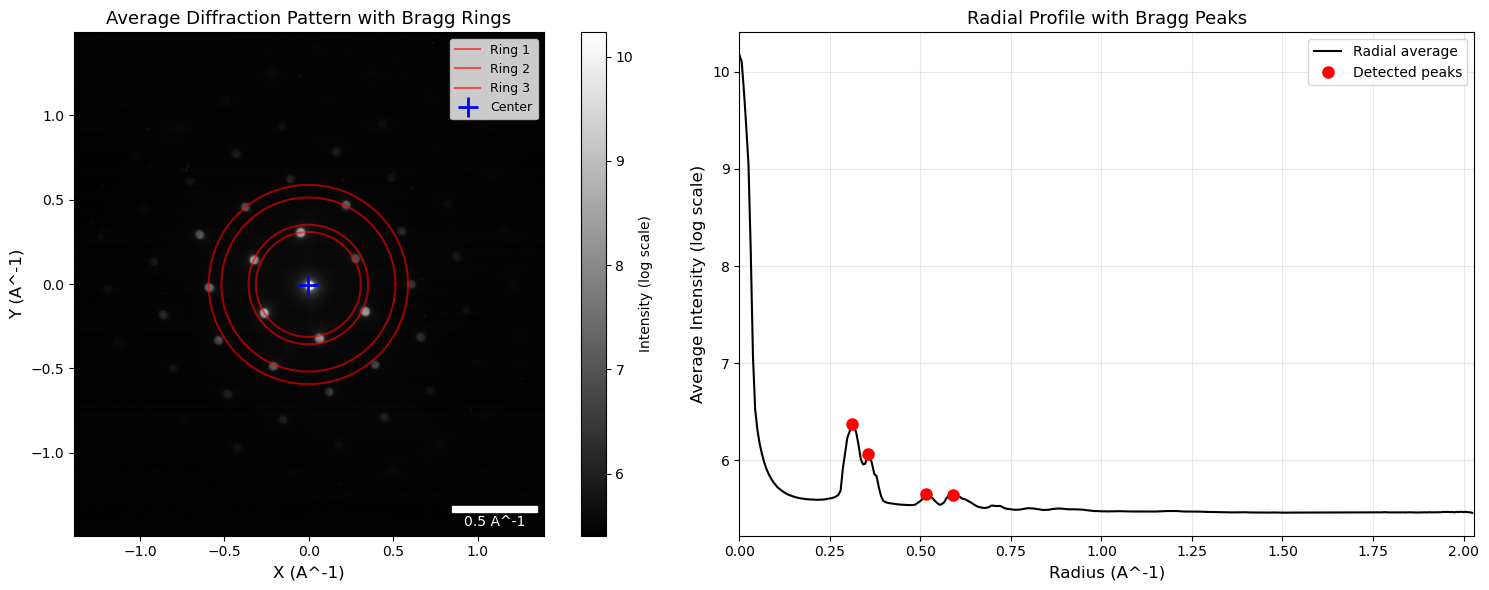

In [155]:
peaks, radial_fig, (radial_ax1, radial_ax2) = find_radial_intensity_profile(sige_calib, calib_params['Q_pixel_size'], calib_params['Q_pixel_units'], 0.5)

In [151]:
# This is just to confirm that 

Si_111 = 3.135 # interplanar spacing of Si (111) planes (Angstroms)
Si_220 = 1.92 # interplanar spacing of Si (220) planes (Angstroms)
Ge_111 = 3.27 # interplanar spacing of Ge (111) planes (Angstroms)
Si_311 = 1.637 # interplanar spacing of Si (311) planes (Angstroms)

measured_d1 = 1/peaks[0] # 1st peak
measured_d2 = 1/peaks[1] # 2nd peak
measured_d3 = 1/peaks[2] # 3rd peak
measured_d4 = 1/peaks[3] # 4th peak

print(f'Interplanar spacing measured from the 1st peak is {measured_d1:.3f} Angstroms')
print(f'Interplanar spacing measured from the 2nd peak is {measured_d2:.3f} Angstroms')
print(f'Interplanar spacing measured from the 3rd peak is {measured_d3:.3f} Angstroms')
print(f'Interplanar spacing measured from the 4th peak is {measured_d4:.3f} Angstroms')

Interplanar spacing measured from the 1st peak is 3.221 Angstroms
Interplanar spacing measured from the 2nd peak is 2.826 Angstroms
Interplanar spacing measured from the 3rd peak is 1.941 Angstroms
Interplanar spacing measured from the 4th peak is 1.695 Angstroms


## A note on the radial intensity profile

Comparing the calculated interplanar spacings to the tabulated interplanar spacings for Si and Ge, it is highly likely that the 1st peak corresponds to the (111) reflection from Si, the 3rd peak corresponds to the (220) reflection from Si, and the 4th peak corresponds to the (311) reflection from Si. The 2nd peak offers inconclusive evidence.

It is also likely that these peaks may correspond to the lattice spacings from pure Si and the SiGe compound. Using Vegard's law and tabulated lattice parameters, one could potentially deduce the composition of Si and Ge in the SiGe compound and confirm these results using the peaks found in this DP.

In [152]:
# Taking the calibrated values and applying them to a new datacube

sige_shifted = sige
sige_shifted.data = sige_calib

## Task 3: Virtual Detector Reconstruction

Generate a Virtual Bright Field (BF) image by integrating the central transmitted disk.

Generate an Annular Dark Field (ADF) image by integrating the scattered electrons in an outer ring.

Compare the Z-contrast in the ADF image to the diffraction contrast in the BF image.

## Function definition to run entire analysis pipeline

In [160]:
def run_pipeline(filename):
    try:
        # Implementing Hyperspy functionalities first to collect some calibration parameters
        data = hs.load(filename)
        s = data.transpose(navigation_axes=[2,3],signal_axes=[0,1]) # the navigation and signal axes in this dataset need to be swapped
        Rpixsize, Rpixunits = s.axes_manager.navigation_axes[0].scale, s.axes_manager.navigation_axes[0].units
        Qpixsize, Qpixunits = s.axes_manager.signal_axes[0].scale, s.axes_manager.signal_axes[0].units
        Rxsize, Rysize = s.axes_manager.navigation_axes[0].size, s.axes_manager.navigation_axes[1].size
        Qysize, Qxsize = s.axes_manager.signal_axes[0].size, s.axes_manager.signal_axes[1].size

        # Implementing py4DSTEM routines
        raw_datacube = p4.import_file(filename)
        datacube = raw_datacube.swap_RQ()

        datacube.calibration.set_R_pixel_size(Rpixsize)
        datacube.calibration.set_R_pixel_units(Rpixunits)
        datacube.set_dim(0, [0, Rpixsize], units=Rpixunits, name="Rx")
        datacube.set_dim(1, [0, Rpixsize], units=Rpixunits, name="Ry")
        if Qpixunits == '1/nm':
            datacube.calibration.set_Q_pixel_size(Qpixsize*0.1)
            datacube.calibration.set_Q_pixel_units('A^-1')
            datacube.set_dim(2, (np.arange(Qxsize) - (Qxsize/2)) * Qpixsize * 0.1, units='A^-1', name="Qx")
            datacube.set_dim(3, (np.arange(Qysize) - (Qysize/2)) * Qpixsize * 0.1, units='A^-1', name="Qy")
        else:
            datacube.calibration.set_Q_pixel_size(Qpixsize)
            datacube.calibration.set_Q_pixel_units(Qpixunits)
            datacube.set_dim(2, (np.arange(Qxsize) - (Qxsize/2)) * Qpixsize, units=Qpixunits, name="Qx")
            datacube.set_dim(3, (np.arange(Qysize) - (Qysize/2)) * Qpixsize, units=Qpixunits, name="Qy")

        datacube_com, ref_com, calibdata = com_calib(datacube)
        peaks, radial_fig, (radial_ax1, radial_ax2) = find_radial_intensity_profile(calibdata, Qpixsize, Qpixunits, 5)

        datacube_calib = datacube
        datacube_calib.data = calibdata

        BF_img_fig, BF_img_ax = create_virtual_image(datacube_calib, 'circle', (Qxsize/2, Qysize/2), 20)
        ADF_img_fig, ADF_img_ax = create_virtual_image(datacube_calib, 'annular', (Qxsize/2, Qysize/2), (30,73))

        calib_params = {
            'R_pixel_size': Rpixsize,
            'R_pixel_units': Rpixunits,
            'Q_pixel_size': Qpixsize,
            'Q_pixel_units': Qpixunits,
            'Shape of R': (Rxsize, Rysize),
            'Shape of Q': (Qxsize, Qysize),
            'Origin_x': ref_com[0],
            'Origin_y': ref_com[1]
        }
        
        return calib_params, datacube_calib, BF_img_fig, BF_img_ax, ADF_img_fig, ADF_img_ax, radial_fig, (radial_ax1, radial_ax2)
        
    except NameError:
        print('Metadata is missing from the 4D STEM dataset.')

## Task 4: Basic 4D-STEM Visualization

Launch the interactive 4D-STEM browser using dataset.show() (if using a local GUI) or py4D.show_image().

Export a publication-quality figure of a virtual ADF image with a scale bar and a perceptually uniform colormap (e.g., magma).

## Running the pipeline and saving important data

Refined center from direct beam: (223.45, 239.55)


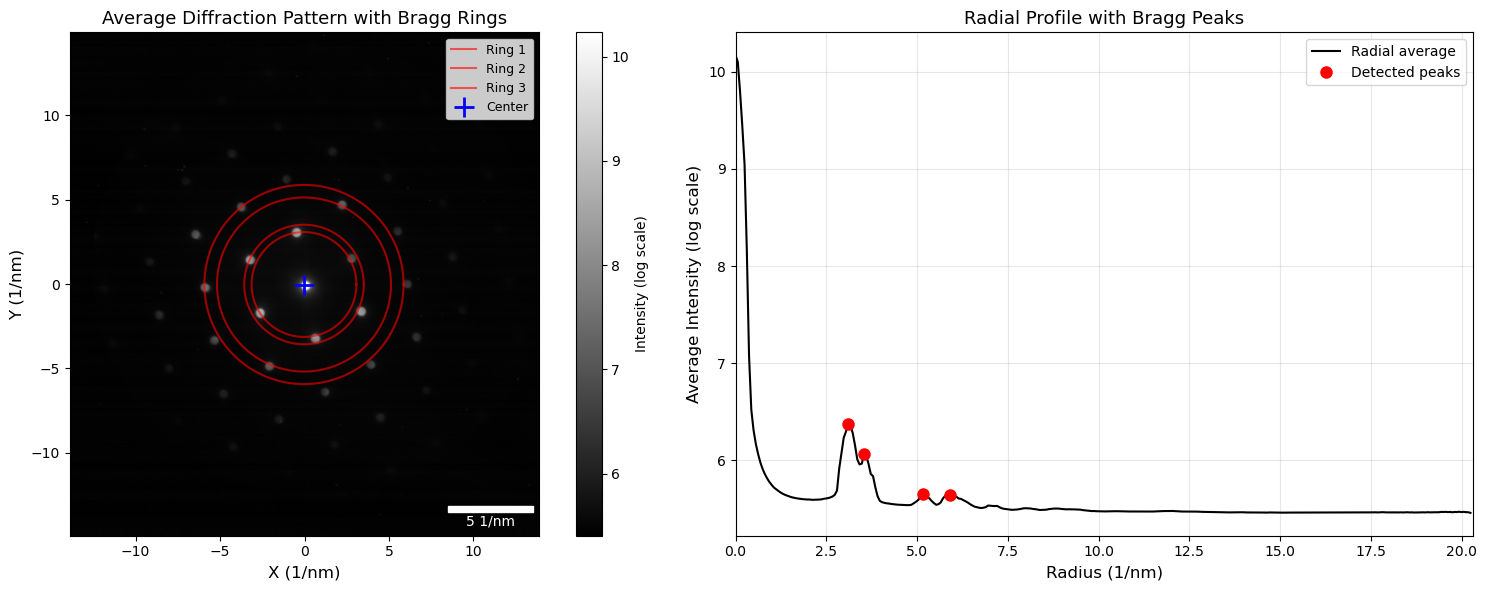

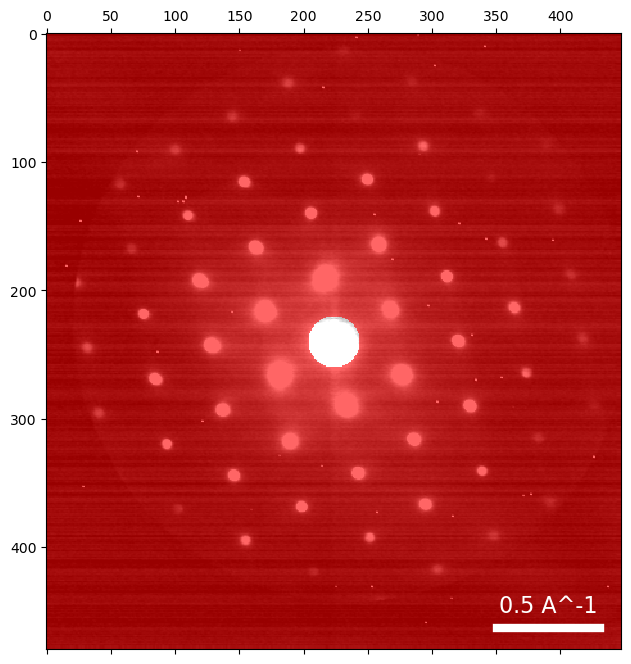

100%|████████████████████████████████████████████████████████████████████████████| 1309/1309 [00:00<00:00, 1464.87it/s]


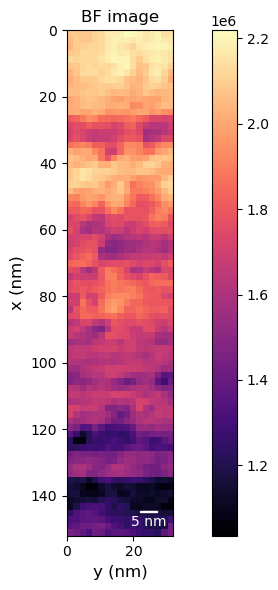

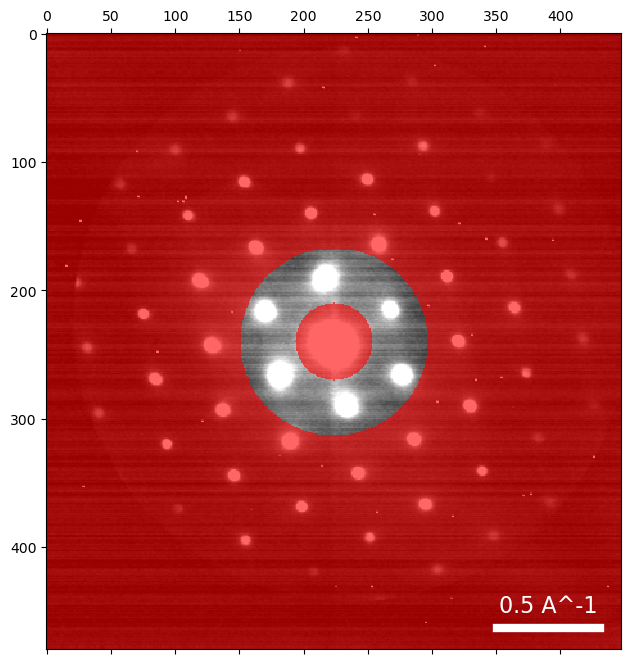

100%|████████████████████████████████████████████████████████████████████████████| 1309/1309 [00:00<00:00, 1589.81it/s]


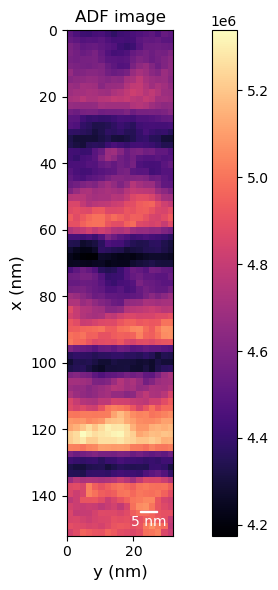

In [167]:
params, datacube_calib, BF_img_fig, BF_img_ax, ADF_img_fig, ADF_img_ax, radial_profile, (radial_ax1, radial_ax2) = run_pipeline('/Users/wkddk/matsci465/Si-SiGe.dm4')

## Performing a line scan on the ADF image

In [200]:
# recollecting the ADF image data
im = ADF_img_ax.images[0]
ADF_img = im.get_array()

In [214]:
real_pixel_size = datacube.calibration.get_R_pixel_size()
            rx = np.arange(datacube.shape[0]) * real_pixel_size
            ry = np.arange(datacube.shape[1]) * real_pixel_size
            
            datacube.get_dp_mean()
            datacube.position_detector(mode=shape, geometry=(center, radius))
            virtual_img = datacube.get_virtual_image(mode=shape, geometry=(center, radius))
    
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            
            im = ax.imshow(virtual_img.data, extent = [ry[0], ry[-1], rx[-1], rx[0]], cmap='magma', origin='upper')
            ax.set_xlabel('y (nm)', fontsize=12)
            ax.set_ylabel('x (nm)', fontsize=12)
            if shape == 'circle' and center == (datacube.shape[2]/2, datacube.shape[3]/2):
                ax.set_title('BF image', fontsize=12)
            elif shape == 'annular' and center == (datacube.shape[2]/2, datacube.shape[3]/2):
                ax.set_title('ADF image', fontsize=12)
            else:
                ax.set_title('Custom mask', fontsize=12)

            scale_len = 5
            scalebar = AnchoredSizeBar(
                transform=ax.transData,
                size=scale_len,
                label=f'{scale_len} nm',
                loc='lower right',
                pad=0.4,
                color='white',
                frameon=False,
                size_vertical=scale_len * 0.07
            )
            ax.add_artist(scalebar)

{'R_pixel_size': 2.0,
 'R_pixel_units': 'nm',
 'Q_pixel_size': 0.06208537146449089,
 'Q_pixel_units': '1/nm',
 'Shape of R': (17, 77),
 'Shape of Q': (480, 448),
 'Origin_x': 239.7202052508977,
 'Origin_y': 223.63286667158408}

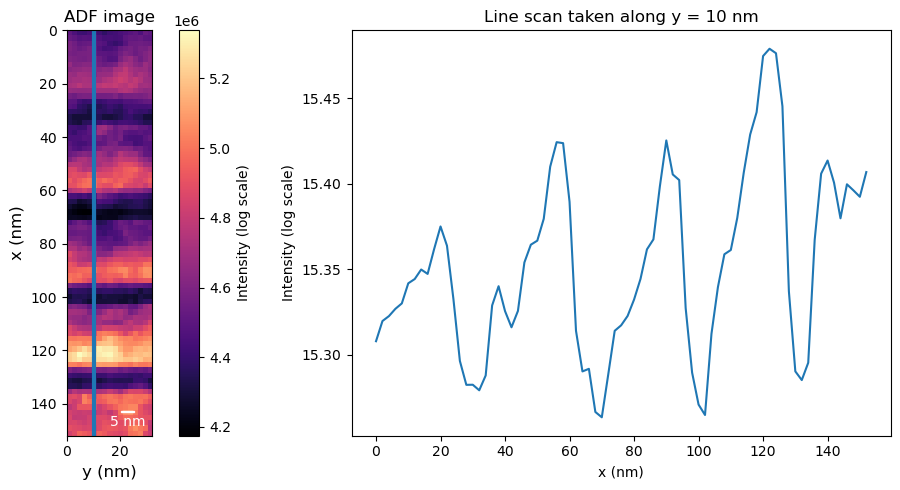

In [236]:
linescanfig, ax = plt.subplots(1, 2, figsize=(12,5))

rx = np.arange(ADF_img.shape[0]) * params['R_pixel_size']
ry = np.arange(ADF_img.shape[1]) * params['R_pixel_size']

im = ax[0].imshow(ADF_img, cmap='magma', extent=[ry[0], ry[-1], rx[-1], rx[0]], origin='upper')
ax[0].axvline(x=10, linewidth=3)
ax[0].set_xlabel('y (nm)', fontsize=12)
ax[0].set_ylabel('x (nm)', fontsize=12)
ax[0].set_title('ADF image')
scalebar = AnchoredSizeBar(
    transform=ax[0].transData,
    size=5,
    label='5 nm',
    loc='lower right',
    pad=0.4,
    color='white',
    frameon=False,
    size_vertical=5 * 0.07
)
ax[0].add_artist(scalebar)
linescanfig.colorbar(im, ax=ax[0], label='Intensity (log scale)')

line_scan = ADF_img[:, 5]
ax[1].plot(rx, np.log1p(line_scan))
ax[1].set_xlabel('x (nm)')
ax[1].set_ylabel('Intensity (log scale)')
ax[1].set_title('Line scan taken along y = 10 nm')

plt.tight_layout()

## Exporting the images

In [195]:
import os

dir_path = '/Users/wkddk/matsci465/assignment_02_figures'

try:
    os.mkdir(dir_path)
    print(f"Directory '{dir}' created successfully.")
except FileExistsError:
    print(f"Directory '{dir}' already exists.")
except FileNotFoundError:
    print(f"Error: Intermediate directories in the path do not exist.")

Directory '<built-in function dir>' already exists.


In [237]:
filenames = [
    'radial_profile.png',
    'BF_image.png',
    'ADF_image.png',
    'line_scan.png'
]

figs = [
    radial_profile,
    BF_img_fig,
    ADF_img_fig,
    linescanfig
]

In [238]:
for i, img in enumerate(filenames):
    full_path = os.path.join(dir_path, img)
    figs[i].savefig(full_path, dpi=300, bbox_inches='tight')
    print(f'Figure saved to {full_path}')

Figure saved to /Users/wkddk/matsci465/assignment_02_figures\radial_profile.png
Figure saved to /Users/wkddk/matsci465/assignment_02_figures\BF_image.png
Figure saved to /Users/wkddk/matsci465/assignment_02_figures\ADF_image.png
Figure saved to /Users/wkddk/matsci465/assignment_02_figures\line_scan.png


## Task 5: Finalize and Submit

Update your README.md with a brief explanation of how virtual detectors allow post-acquisition imaging.

Push the completed Week 02 notebook to your GitHub repository.

Submit the repository link on Canvas.

In [ ]:
# Your code here